# NASA C-MAPSS FD001 — RUL Prediction
Two-layer LSTM on sensor degradation data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Run this once in the notebook kernel if dependencies are missing:
# %pip install numpy pandas matplotlib scikit-learn tensorflow jupyter

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow import keras
from tensorflow.keras import layers

W           = 40
TRAIN_SPLIT = 80
RUL_CAP     = 125
COL_NAMES   = ['engine_id', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]
DROP_COLS   = ['os1', 'os2', 'os3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']

## Load

In [3]:
def load_data(path):
    df = pd.read_csv(path, sep='\s+', engine='python', header=None, names=COL_NAMES)
    return df

df = load_data('train_FD001.txt')
print(df.shape)
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amber\AppData\Local\Temp\ipykernel_20044\3023732230.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(path, sep='\s+', engine='python', header=None, names=COL_NAMES)


(20631, 26)


,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
def sanity_check(df):
    print(df.isnull().sum())
    print(df['engine_id'].nunique(), 'engines')
    print(df.dtypes)

sanity_check(df)

engine_id    0
cycle        0
os1          0
os2          0
os3          0
s1           0
s2           0
s3           0
s4           0
s5           0
s6           0
s7           0
s8           0
s9           0
s10          0
s11          0
s12          0
s13          0
s14          0
s15          0
s16          0
s17          0
s18          0
s19          0
s20          0
s21          0
dtype: int64
100 engines
engine_id      int64
cycle          int64
os1          float64
os2          float64
os3          float64
s1           float64
s2           float64
s3           float64
s4           float64
s5           float64
s6           float64
s7           float64
s8           float64
s9           float64
s10          float64
s11          float64
s12          float64
s13          float64
s14          float64
s15          float64
s16          float64
s17            int64
s18            int64
s19          float64
s20          float64
s21          float64
dtype: object


## Preprocessing

In [5]:
def compute_rul(df):
    max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycle.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycle, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df['RUL'] = df['RUL'].clip(upper=RUL_CAP)
    df = df.drop(columns=['max_cycle'])
    return df

df = compute_rul(df)
df[df['engine_id'] == 1].tail(3)

,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


In [6]:
def drop_sensors(df):
    new_df = df.drop(columns=DROP_COLS)
    sensor_columns = [c for c in new_df.columns if c.startswith('s')]
    return new_df, sensor_columns

new_df, sensor_columns = drop_sensors(df)
print(sensor_columns)

['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## Visualise

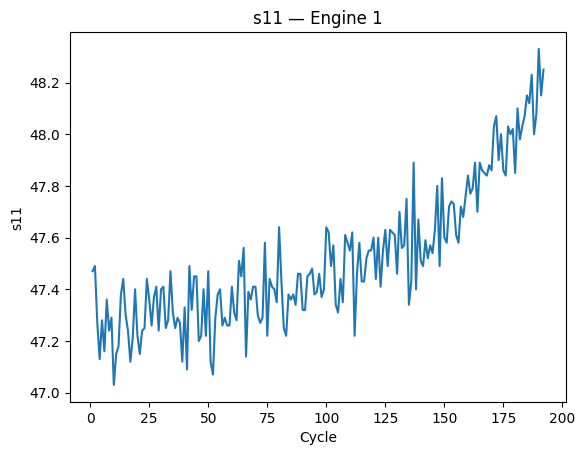

In [7]:
def plot_sensor(df, engine_id=1, sensor='s11'):
    eng = df[df['engine_id'] == engine_id].sort_values('cycle')
    plt.plot(eng['cycle'], eng[sensor])
    plt.xlabel('Cycle')
    plt.ylabel(sensor)
    plt.title(f'{sensor} — Engine {engine_id}')
    plt.show()

plot_sensor(new_df)

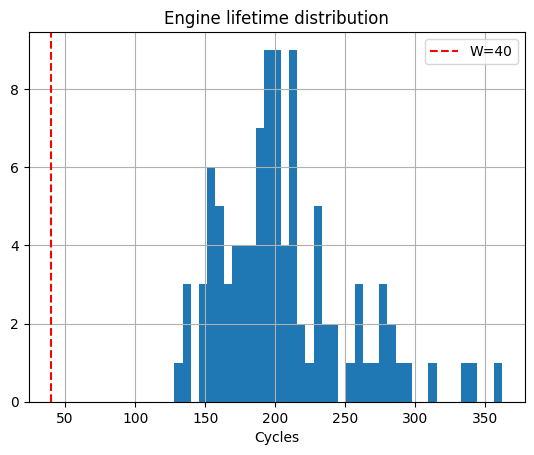

Min: 128  Max: 362


In [8]:
def plot_lifetimes(df):
    lifetimes = df.groupby('engine_id')['cycle'].max()
    lifetimes.hist(bins=40)
    plt.axvline(W, color='red', linestyle='--', label=f'W={W}')
    plt.xlabel('Cycles')
    plt.title('Engine lifetime distribution')
    plt.legend()
    plt.show()
    print(f'Min: {lifetimes.min()}  Max: {lifetimes.max()}')

plot_lifetimes(new_df)

## Split + Scale

In [9]:
def split_engines(df, train_split=TRAIN_SPLIT):
    all_ids  = df['engine_id'].unique()
    train_df = df[df['engine_id'].isin(all_ids[:train_split])].copy()
    val_df   = df[df['engine_id'].isin(all_ids[train_split:])].copy()
    return train_df, val_df

train_df, val_df = split_engines(new_df)
print(train_df['engine_id'].nunique(), 'train engines')
print(val_df['engine_id'].nunique(), 'val engines')

80 train engines
20 val engines


In [10]:
def fit_preprocessor(train_df, sensor_columns):
    preprocessor = Pipeline([
        ('imputer', SimpleImputer()),
        ('scaler',  StandardScaler())
    ])
    preprocessor.fit(train_df[sensor_columns])
    return preprocessor

preprocessor = fit_preprocessor(train_df, sensor_columns)

In [11]:
def scale_data(preprocessor, train_df, val_df, sensor_columns):
    train_df[sensor_columns] = preprocessor.transform(train_df[sensor_columns])
    val_df[sensor_columns]   = preprocessor.transform(val_df[sensor_columns])
    return train_df, val_df

train_df, val_df = scale_data(preprocessor, train_df, val_df, sensor_columns)
print(train_df[sensor_columns].mean().round(2))
print(train_df[sensor_columns].std().round(2))

s2    -0.0
s3    -0.0
s4     0.0
s7    -0.0
s8     0.0
s9     0.0
s11   -0.0
s12    0.0
s13   -0.0
s14    0.0
s15    0.0
s17   -0.0
s20    0.0
s21   -0.0
dtype: float64
s2     1.0
s3     1.0
s4     1.0
s7     1.0
s8     1.0
s9     1.0
s11    1.0
s12    1.0
s13    1.0
s14    1.0
s15    1.0
s17    1.0
s20    1.0
s21    1.0
dtype: float64


## Windowing

In [12]:
def create_windows(data, rul, W):
    T           = len(data)
    num_windows = T - W + 1
    X = np.zeros((num_windows, W, data.shape[1]))
    Y = np.zeros(num_windows)
    for i in range(num_windows):
        X[i] = data[i : i + W]
        Y[i] = rul[i + W - 1]
    return X, Y

In [13]:
def build_windows(df, sensor_columns, W):
    all_x, all_y = [], []
    for eng_id, group in df.groupby('engine_id'):
        group = group.sort_values('cycle')
        data  = group[sensor_columns].values
        rul   = group['RUL'].values
        if len(data) < W:
            continue
        X_eng, Y_eng = create_windows(data, rul, W)
        all_x.append(X_eng)
        all_y.append(Y_eng)
    return np.concatenate(all_x, axis=0), np.concatenate(all_y, axis=0)

X_train, Y_train = build_windows(train_df, sensor_columns, W)
X_val,   Y_val   = build_windows(val_df,   sensor_columns, W)
print('Train:', X_train.shape, Y_train.shape)
print('Val:  ', X_val.shape,   Y_val.shape)

Train: (13018, 40, 14) (13018,)
Val:   (3713, 40, 14) (3713,)


## Verify

In [14]:
def run_assertions(X, Y, sensor_columns, W):
    assert X.ndim == 3
    assert X.shape[1] == W
    assert X.shape[2] == len(sensor_columns)
    assert len(X) == len(Y)
    assert not np.isnan(X).any()
    assert Y.min() >= 0
    print('All checks passed')

run_assertions(X_train, Y_train, sensor_columns, W)

All checks passed


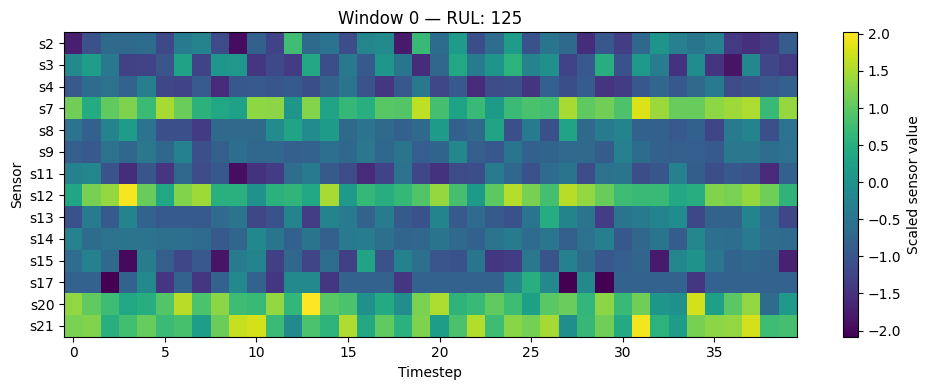

In [15]:
def plot_heatmap(X, Y, sensor_columns):
    plt.figure(figsize=(10, 4))
    plt.imshow(X[0].T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Scaled sensor value')
    plt.xlabel('Timestep')
    plt.ylabel('Sensor')
    plt.yticks(range(len(sensor_columns)), sensor_columns)
    plt.title(f'Window 0 — RUL: {Y[0]:.0f}')
    plt.tight_layout()
    plt.show()

plot_heatmap(X_train, Y_train, sensor_columns)

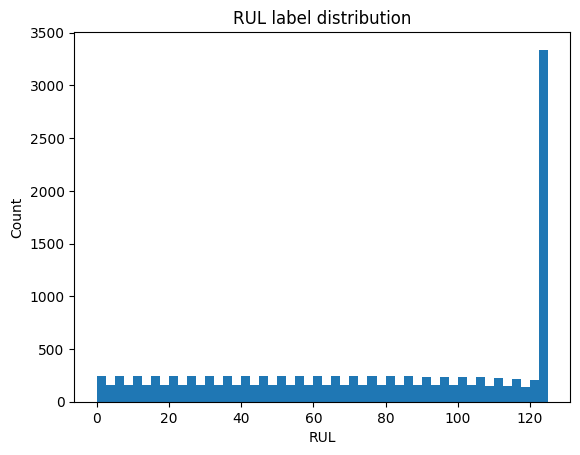

In [16]:
def plot_rul_dist(Y):
    plt.hist(Y, bins=50)
    plt.xlabel('RUL')
    plt.ylabel('Count')
    plt.title('RUL label distribution')
    plt.show()

plot_rul_dist(Y_train)

## Models

In [17]:
def build_model_v1(W, n_features):
    # baseline — single LSTM
    # took ~20 epochs to converge, val loss stayed ~1500
    # keeping this here to show what changed with v2
    model = keras.Sequential([
        layers.Input(shape=(W, n_features)),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model_v1 = build_model_v1(W, len(sensor_columns))
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def build_model_v2(W, n_features):
    # return_sequences=True passes all W timestep outputs to the second LSTM
    # instead of just the last one — this is what cut convergence from
    # ~20 epochs down to ~8 and dropped val loss under control
    model = keras.Sequential([
        layers.Input(shape=(W, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model_v2 = build_model_v2(W, len(sensor_columns))
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 40, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,729 (131.75 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [19]:
def train_model(model, X_train, Y_train, X_val, Y_val, epochs=40, batch_size=64):
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=5,
                restore_best_weights=True
            )
        ]
    )
    return history

history = train_model(model_v2, X_train, Y_train, X_val, Y_val)

Epoch 1/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 4386.1079 - val_loss: 1663.2444
Epoch 2/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 588.8438 - val_loss: 252.6030
Epoch 3/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 242.6796 - val_loss: 188.1390
Epoch 4/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 206.2248 - val_loss: 150.7231
Epoch 5/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 184.9422 - val_loss: 251.0070
Epoch 6/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 180.8291 - val_loss: 194.3304
Epoch 7/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 164.3136 - val_loss: 174.1909
Epoch 8/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 159.3464 - val_loss: 188.5285
Epoch 9/40
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 148.6834 - val_loss: 240.6370


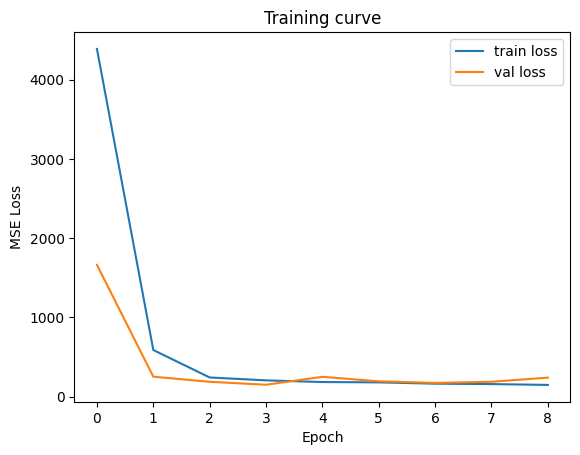

In [20]:
def plot_training(history):
    plt.plot(history.history['loss'],     label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training curve')
    plt.legend()
    plt.show()

plot_training(history)

## Evaluate — Validation

In [21]:
def evaluate(model, X, Y):
    y_pred = model.predict(X).flatten()
    rmse   = np.sqrt(mean_squared_error(Y, y_pred))
    mae    = mean_absolute_error(Y, y_pred)
    print(f'RMSE: {rmse:.2f} cycles')
    print(f'MAE:  {mae:.2f} cycles')
    return y_pred

y_pred = evaluate(model_v2, X_val, Y_val)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 12.28 cycles
MAE:  9.45 cycles


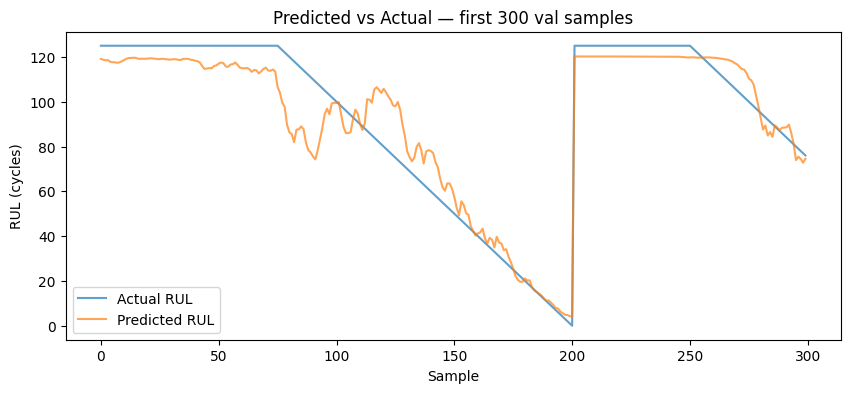

In [22]:
def plot_predictions(Y, y_pred, n=300):
    plt.figure(figsize=(10, 4))
    plt.plot(Y[:n],      label='Actual RUL',    alpha=0.7)
    plt.plot(y_pred[:n], label='Predicted RUL', alpha=0.7)
    plt.xlabel('Sample')
    plt.ylabel('RUL (cycles)')
    plt.title(f'Predicted vs Actual — first {n} val samples')
    plt.legend()
    plt.show()

plot_predictions(Y_val, y_pred)

## Evaluate — Test Set

In [23]:
def load_test_data(path='test_FD001.txt'):
    test_df = pd.read_csv(path, sep='\s+', engine='python', header=None, names=COL_NAMES)
    return test_df

def load_rul_labels(path='RUL_FD001.txt'):
    y_true = pd.read_csv(path, header=None, names=['RUL'])['RUL'].values
    return y_true

test_df = load_test_data()
y_true  = load_rul_labels()
print(test_df.shape, y_true.shape)

(13096, 26) (100,)


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\amber\AppData\Local\Temp\ipykernel_20044\3124753318.py:2: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv(path, sep='\s+', engine='python', header=None, names=COL_NAMES)


In [24]:
def predict_test(model, test_df, sensor_columns, preprocessor, W, RUL_CAP):
    test_preds = []
    for eng_id, group in test_df.groupby('engine_id'):
        group = group.sort_values('cycle')
        group = group.copy()
        group[sensor_columns] = preprocessor.transform(group[sensor_columns])
        data = group[sensor_columns].values
        if len(data) < W:
            pad  = np.zeros((W - len(data), data.shape[1]))
            data = np.vstack([pad, data])
        else:
            data = data[-W:]
        window = data[np.newaxis, :, :]
        pred   = model.predict(window, verbose=0)[0][0]
        pred   = np.clip(pred, 0, RUL_CAP)
        test_preds.append(pred)
    return np.array(test_preds)

test_preds = predict_test(model_v2, test_df, sensor_columns, preprocessor, W, RUL_CAP)
print(test_preds.shape)

(100,)


Test RMSE: 14.64 cycles
Test MAE:  11.23 cycles


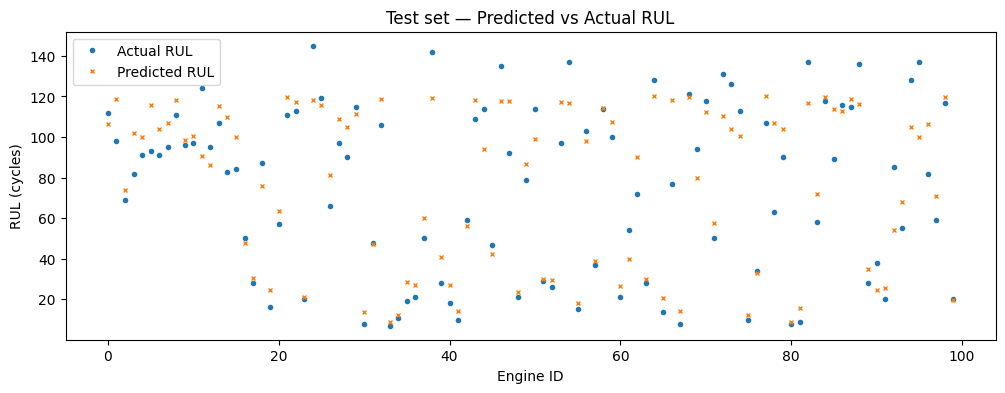

In [25]:
def evaluate_test(y_true, test_preds):
    rmse = np.sqrt(mean_squared_error(y_true, test_preds))
    mae  = mean_absolute_error(y_true, test_preds)
    print(f'Test RMSE: {rmse:.2f} cycles')
    print(f'Test MAE:  {mae:.2f} cycles')
    plt.figure(figsize=(12, 4))
    plt.plot(y_true,      label='Actual RUL',    marker='o', markersize=3, linewidth=0)
    plt.plot(test_preds,  label='Predicted RUL', marker='x', markersize=3, linewidth=0)
    plt.xlabel('Engine ID')
    plt.ylabel('RUL (cycles)')
    plt.title('Test set — Predicted vs Actual RUL')
    plt.legend()
    plt.show()

evaluate_test(y_true, test_preds)

RF Val RMSE: 13.05, MAE: 9.97
test_preds_rf shape: (100,) y_true shape: (100,)
RF Test RMSE: 13.45, MAE: 9.81


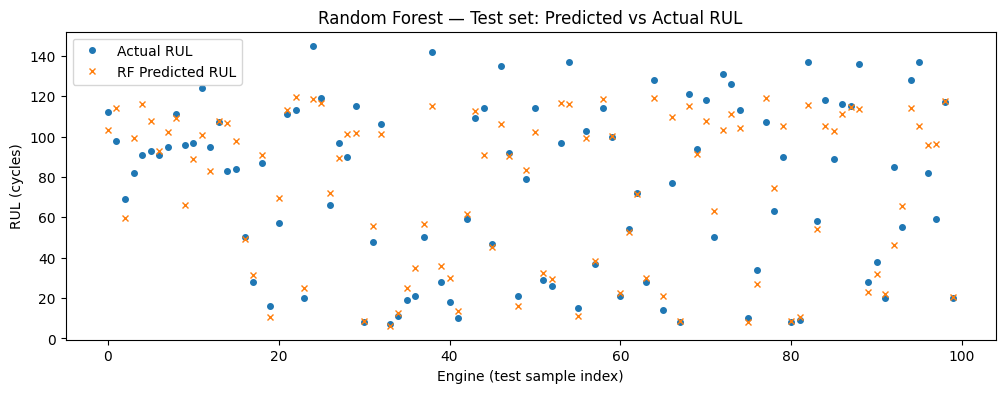

In [27]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

def agg_features(X):
    # X: (N, W, F) -> returns (N, F*6)
    N,W,F = X.shape
    t = np.arange(W)
    feats = []
    for i in range(N):
        x = X[i]            # (W, F)
        mean = x.mean(axis=0)
        std  = x.std(axis=0)
        mn   = x.min(axis=0)
        mx   = x.max(axis=0)
        last = x[-1,:]
        # slopes per sensor
        slopes = np.array([np.polyfit(t, x[:,j], 1)[0] for j in range(F)])
        feats.append(np.concatenate([mean,std,mn,mx,last,slopes]))
    return np.vstack(feats)

# Train RF on aggregated window features (validation comparison)
Xf_train = agg_features(X_train)
Xf_val   = agg_features(X_val)

rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(Xf_train, Y_train)
y_pred = rf.predict(Xf_val)
rmse = np.sqrt(mean_squared_error(Y_val, y_pred))
mae  = mean_absolute_error(Y_val, y_pred)
print(f'RF Val RMSE: {rmse:.2f}, MAE: {mae:.2f}')

# Evaluate RF on the test set (one prediction per engine)
def rf_predict_test(rf, test_df, sensor_columns, preprocessor, W, RUL_CAP):
    preds = []
    for eng_id, group in test_df.groupby('engine_id'):
        group = group.sort_values('cycle').copy()
        group[sensor_columns] = preprocessor.transform(group[sensor_columns])
        data = group[sensor_columns].values
        if len(data) < W:
            pad  = np.zeros((W - len(data), data.shape[1]))
            data = np.vstack([pad, data])
        else:
            data = data[-W:]
        Xf = agg_features(data[np.newaxis, :, :])
        pred = rf.predict(Xf)[0]
        pred = np.clip(pred, 0, RUL_CAP)
        preds.append(pred)
    return np.array(preds)

# Ensure test data and true labels are loaded
try:
    test_df
    y_true
except NameError:
    test_df = load_test_data()
    y_true  = load_rul_labels()

test_preds_rf = rf_predict_test(rf, test_df, sensor_columns, preprocessor, W, RUL_CAP)
print('test_preds_rf shape:', test_preds_rf.shape, 'y_true shape:', y_true.shape)
rmse_rf = np.sqrt(mean_squared_error(y_true, test_preds_rf))
mae_rf  = mean_absolute_error(y_true, test_preds_rf)
print(f'RF Test RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}')

# Plot comparison on test set
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(y_true, label='Actual RUL', marker='o', markersize=4, linewidth=0)
plt.plot(test_preds_rf, label='RF Predicted RUL', marker='x', markersize=4, linewidth=0)
plt.xlabel('Engine (test sample index)')
plt.ylabel('RUL (cycles)')
plt.title('Random Forest — Test set: Predicted vs Actual RUL')
plt.legend()
plt.show()

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 6482.7910 - val_loss: 5539.8560
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 2950.7209 - val_loss: 1670.9833
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 756.0296 - val_loss: 450.7654
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 290.0229 - val_loss: 197.1586
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 210.6100 - val_loss: 172.8913
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 184.0687 - val_loss: 145.0367
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 172.4533 - val_loss: 211.0159
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 164.7141 - val_loss: 153.7610
Epoch 9/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 152.8316 - val_loss: 203.3298
Epoch 10/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 149.2922 - val_loss: 166.8646
Epoch 11/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 140.9699 - val_loss: 17

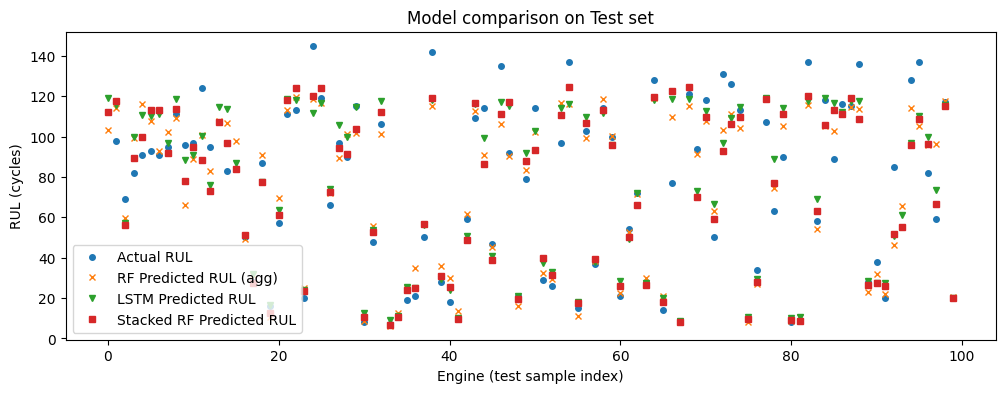

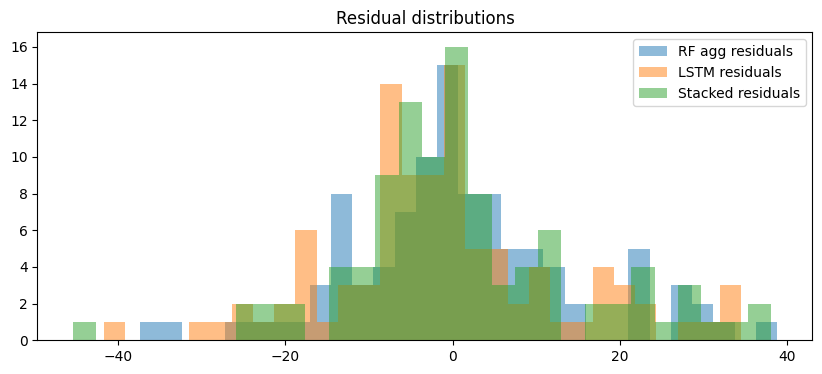

        model  test_RMSE  test_MAE
0    RF (agg)      13.45      9.81
1        LSTM      14.04     10.36
2  Stacked RF      14.06      9.99


In [28]:
# Stacking: LSTM predictions as a feature for Random Forest
# Train a small LSTM (reuse build_model_v2 and train_model)
lstm = build_model_v2(W, X_train.shape[2])
# use fewer epochs for quick iteration; early stopping is active
history_lstm = train_model(lstm, X_train, Y_train, X_val, Y_val, epochs=20, batch_size=128)

# Get LSTM window-level predictions for train/val
lstm_pred_train = lstm.predict(X_train).flatten()
lstm_pred_val   = lstm.predict(X_val).flatten()

# Aggregate window features (already defined agg_features above)
Xf_train = agg_features(X_train)
Xf_val   = agg_features(X_val)

# Combine aggregated features with LSTM prediction
Xf_train_stack = np.hstack([Xf_train, lstm_pred_train.reshape(-1,1)])
Xf_val_stack   = np.hstack([Xf_val,   lstm_pred_val.reshape(-1,1)])

# Train RF on stacked features
from sklearn.ensemble import RandomForestRegressor
rf_stack = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_stack.fit(Xf_train_stack, Y_train)

# Validation evaluation
yval_pred_stack = rf_stack.predict(Xf_val_stack)
rmse_stack_val = np.sqrt(mean_squared_error(Y_val, yval_pred_stack))
mae_stack_val  = mean_absolute_error(Y_val, yval_pred_stack)
print(f'Stacked RF Val RMSE: {rmse_stack_val:.2f}, MAE: {mae_stack_val:.2f}')

# Test set predictions: generate per-engine features and lstm pred then combine

def rf_stack_predict_test(rf, lstm, test_df, sensor_columns, preprocessor, W, RUL_CAP):
    preds = []
    lstm_preds = []
    for eng_id, group in test_df.groupby('engine_id'):
        group = group.sort_values('cycle').copy()
        group[sensor_columns] = preprocessor.transform(group[sensor_columns])
        data = group[sensor_columns].values
        if len(data) < W:
            pad  = np.zeros((W - len(data), data.shape[1]))
            data = np.vstack([pad, data])
        else:
            data = data[-W:]
        # LSTM window prediction
        lp = lstm.predict(data[np.newaxis,:,:], verbose=0)[0,0]
        # aggregated features
        Xf = agg_features(data[np.newaxis,:,:])[0]
        feat = np.hstack([Xf, lp])
        pred = rf.predict(feat.reshape(1,-1))[0]
        pred = np.clip(pred, 0, RUL_CAP)
        preds.append(pred)
        lstm_preds.append(lp)
    return np.array(preds), np.array(lstm_preds)

stack_preds_test, lstm_preds_test = rf_stack_predict_test(rf_stack, lstm, test_df, sensor_columns, preprocessor, W, RUL_CAP)

rmse_stack_test = np.sqrt(mean_squared_error(y_true, stack_preds_test))
mae_stack_test  = mean_absolute_error(y_true, stack_preds_test)
print(f'Stacked RF Test RMSE: {rmse_stack_test:.2f}, MAE: {mae_stack_test:.2f}')

# Also compute plain LSTM test predictions (one per engine using last window)
def lstm_predict_test(lstm, test_df, sensor_columns, preprocessor, W, RUL_CAP):
    preds = []
    for eng_id, group in test_df.groupby('engine_id'):
        group = group.sort_values('cycle').copy()
        group[sensor_columns] = preprocessor.transform(group[sensor_columns])
        data = group[sensor_columns].values
        if len(data) < W:
            pad  = np.zeros((W - len(data), data.shape[1]))
            data = np.vstack([pad, data])
        else:
            data = data[-W:]
        pred = lstm.predict(data[np.newaxis,:,:], verbose=0)[0,0]
        pred = np.clip(pred, 0, RUL_CAP)
        preds.append(pred)
    return np.array(preds)

lstm_test_preds = lstm_predict_test(lstm, test_df, sensor_columns, preprocessor, W, RUL_CAP)
rmse_lstm_test = np.sqrt(mean_squared_error(y_true, lstm_test_preds))
mae_lstm_test  = mean_absolute_error(y_true, lstm_test_preds)
print(f'LSTM Test RMSE: {rmse_lstm_test:.2f}, MAE: {mae_lstm_test:.2f}')

# Compare: plot actual vs predictions for LSTM, RF baseline, and Stacked RF
plt.figure(figsize=(12,4))
plt.plot(y_true, label='Actual RUL', marker='o', markersize=4, linewidth=0)
plt.plot(test_preds_rf, label='RF Predicted RUL (agg)', marker='x', markersize=4, linewidth=0)
plt.plot(lstm_test_preds, label='LSTM Predicted RUL', marker='v', markersize=4, linewidth=0)
plt.plot(stack_preds_test, label='Stacked RF Predicted RUL', marker='s', markersize=4, linewidth=0)
plt.xlabel('Engine (test sample index)')
plt.ylabel('RUL (cycles)')
plt.title('Model comparison on Test set')
plt.legend()
plt.show()

# Residual histograms
plt.figure(figsize=(10,4))
plt.hist(y_true - test_preds_rf, bins=30, alpha=0.5, label='RF agg residuals')
plt.hist(y_true - lstm_test_preds, bins=30, alpha=0.5, label='LSTM residuals')
plt.hist(y_true - stack_preds_test, bins=30, alpha=0.5, label='Stacked residuals')
plt.legend()
plt.title('Residual distributions')
plt.show()

# Print summary table
import pandas as pd
summary = pd.DataFrame({
    'model': ['RF (agg)', 'LSTM', 'Stacked RF'],
    'test_RMSE': [np.round(np.sqrt(mean_squared_error(y_true, test_preds_rf)),2), np.round(rmse_lstm_test,2), np.round(rmse_stack_test,2)],
    'test_MAE' : [np.round(mean_absolute_error(y_true, test_preds_rf),2), np.round(mae_lstm_test,2), np.round(mae_stack_test,2)]
})
print(summary)
